In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\athar\coding\YUVAL\logistics_analysis\data\dynamic_supply_chain_logistics_dataset.csv', parse_dates=['timestamp'])

print("Fulfillment rate:", df['order_fulfillment_status'].mean())
print("Avg delivery time deviation (hrs):", df['delivery_time_deviation'].mean())
print("% High Risk hours:", (df['risk_classification'] == 'High Risk').mean())
print("Avg shipping cost:", df['shipping_costs'].mean())
print("Avg supplier reliability:", df['supplier_reliability_score'].mean())

print("Unique lat/lon pairs:", df[['vehicle_gps_latitude','vehicle_gps_longitude']].drop_duplicates().shape[0])

Fulfillment rate: 0.6007395524245416
Avg delivery time deviation (hrs): 5.177648068922158
% High Risk hours: 0.7467331981911742
Avg shipping cost: 459.3744517974708
Avg supplier reliability: 0.5008498907839203
Unique lat/lon pairs: 32065


In [3]:
print(df['vehicle_gps_latitude'].min(), df['vehicle_gps_latitude'].max())
print(df['vehicle_gps_longitude'].min(), df['vehicle_gps_longitude'].max())

30.00000000000937 49.99999974528573
-119.99999842346357 -70.00000000027708


delivery_time_deviation        1.000000
fuel_consumption_rate          0.012495
port_congestion_level          0.010612
delay_probability              0.005530
fatigue_monitoring_score       0.003491
disruption_likelihood_score    0.002622
traffic_congestion_level       0.000510
weather_condition_severity    -0.000541
driver_behavior_score         -0.003969
Name: delivery_time_deviation, dtype: float64


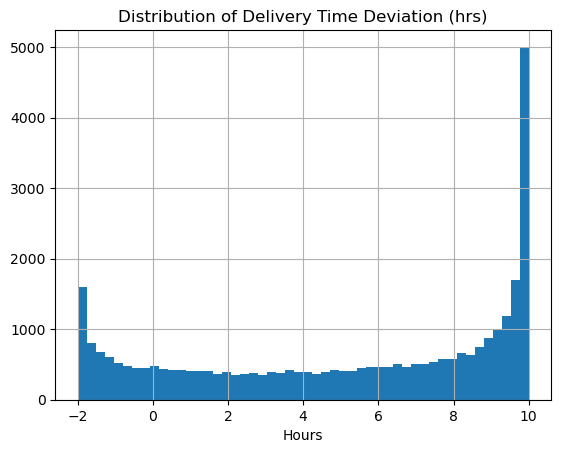

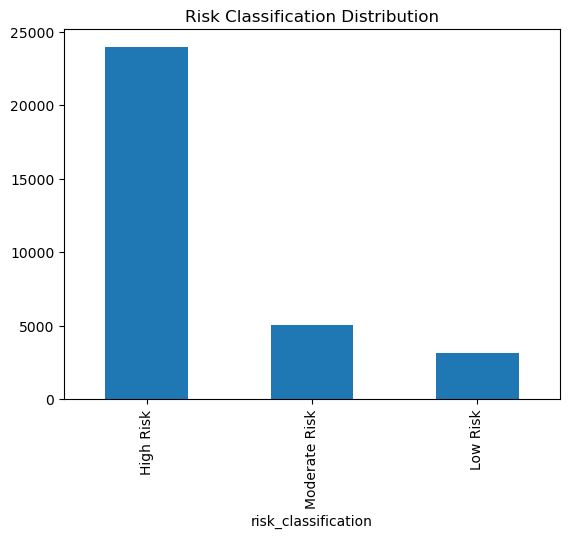

In [4]:
import matplotlib.pyplot as plt

# Which factors actually correlate with delay?
numeric_cols = ['traffic_congestion_level', 'weather_condition_severity', 'port_congestion_level',
                 'fuel_consumption_rate', 'driver_behavior_score', 'fatigue_monitoring_score',
                 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation']

corr = df[numeric_cols].corr()['delivery_time_deviation'].sort_values(ascending=False)
print(corr)

# Distribution of the target you'll regress on
df['delivery_time_deviation'].hist(bins=50)
plt.title('Distribution of Delivery Time Deviation (hrs)')
plt.xlabel('Hours')
plt.show()

# Risk class imbalance, visually
df['risk_classification'].value_counts().plot(kind='bar')
plt.title('Risk Classification Distribution')
plt.show()

In [5]:
numeric_cols = ['traffic_congestion_level', 'weather_condition_severity', 'port_congestion_level',
                 'fuel_consumption_rate', 'driver_behavior_score', 'fatigue_monitoring_score',
                 'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation']

print(df[numeric_cols].corr()['delay_probability'].sort_values(ascending=False))
print()
print(df[numeric_cols].corr(method='spearman')['delivery_time_deviation'].sort_values(ascending=False))

delay_probability              1.000000
port_congestion_level          0.008972
delivery_time_deviation        0.005530
weather_condition_severity     0.001503
fatigue_monitoring_score       0.001070
traffic_congestion_level      -0.003790
driver_behavior_score         -0.003919
disruption_likelihood_score   -0.008175
fuel_consumption_rate         -0.013655
Name: delay_probability, dtype: float64

delivery_time_deviation        1.000000
port_congestion_level          0.011832
fuel_consumption_rate          0.010885
delay_probability              0.006651
disruption_likelihood_score    0.003329
weather_condition_severity     0.000377
fatigue_monitoring_score      -0.000053
traffic_congestion_level      -0.003208
driver_behavior_score         -0.003464
Name: delivery_time_deviation, dtype: float64


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = ['traffic_congestion_level', 'weather_condition_severity', 'port_congestion_level',
            'fuel_consumption_rate', 'driver_behavior_score', 'fatigue_monitoring_score',
            'disruption_likelihood_score']

X = df[features]
y = df['delivery_time_deviation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

MAE: 3.7036601272264527
R²: 0.0004450622321853226


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features_clean = ['traffic_congestion_level', 'weather_condition_severity', 'port_congestion_level',
                   'fuel_consumption_rate', 'driver_behavior_score', 'fatigue_monitoring_score']

X = df[features_clean]
y = df['risk_classification']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print(classification_report(y_test, preds))

c:\Users\athar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\athar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

    High Risk       0.75      1.00      0.86      4789
     Low Risk       0.00      0.00      0.00       622
Moderate Risk       1.00      0.00      0.00      1002

     accuracy                           0.75      6413
    macro avg       0.58      0.33      0.29      6413
 weighted avg       0.71      0.75      0.64      6413



c:\Users\athar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


c:\Users\athar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\athar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\athar\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\athar\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\athar\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

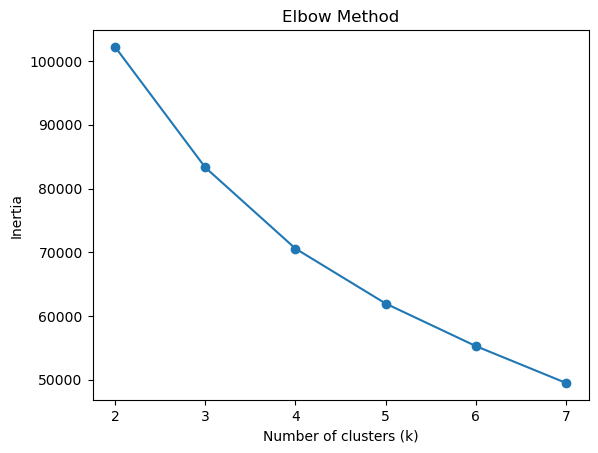

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cluster_features = ['traffic_congestion_level', 'weather_condition_severity',
                     'port_congestion_level', 'fatigue_monitoring_score']

X = df[cluster_features]
X_scaled = StandardScaler().fit_transform(X)

inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 8), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [13]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# Profile each cluster — what does each group actually look like?
print(df.groupby('cluster')[cluster_features].mean())
print()
print(df['cluster'].value_counts())

         traffic_congestion_level  weather_condition_severity  \
cluster                                                         
0                        5.027374                    0.498340   
1                        1.643231                    0.506263   
2                        4.999230                    0.490578   
3                        8.296841                    0.495424   

         port_congestion_level  fatigue_monitoring_score  
cluster                                                   
0                     1.901456                  0.606344  
1                     8.540905                  0.812939  
2                     8.440580                  0.166436  
3                     8.548443                  0.824589  

cluster
2    8291
3    8175
1    8169
0    7430
Name: count, dtype: int64


In [14]:
import pandas as pd
print(pd.crosstab(df['cluster'], df['risk_classification'], normalize='index'))

risk_classification  High Risk  Low Risk  Moderate Risk
cluster                                                
0                     0.743069  0.096231       0.160700
1                     0.749296  0.097686       0.153018
2                     0.745387  0.096731       0.157882
3                     0.748869  0.097248       0.153884
